# Z4 PRS long-$\eta$ $\beta_4$ scan — analysis

Scan directory `scan_z4_prs_long/`: $\mu=1$, $N=1024$, $L=358.4$, PRS from $t_0$,
$t_{\rm max}=150$, $\beta_4 \in \{0.1, 0.3, 0.5, 0.7, 0.9\}$ plus a $\beta_4=0.9$
hi-res cross-check ($L=279$, 4 cells on the *adjacent* wall).

**Science target:** scaling of the **non-adjacent** ($\pi$-jump, $\mathcal{A}_2$) walls.
The BVP gives $\bar\sigma_{\rm opp} = \frac{2\sqrt2}{3(1-\beta_4)}$ and
$\bar\sigma_{\rm opp} = 2\bar\sigma_{\rm adj}$ **exactly at $\beta_4 = 1/3$**
(Z2$\times$Z2 factorization): non-adjacent walls are unstable to splitting into two adjacent
walls for $\beta_4<1/3$ and bound for $\beta_4>1/3$.

**Axis convention:** the x-axis is **program time $\eta$** (column 0 of every output
file). Here $H_0=\mu$ and the fixed radiation background give $a = 1+\eta$, but we
*label* $\eta$ — do not call it $a$ (breaks the moment $H_0/\mu \neq 1$).
Physical conformal time is $\tau = \eta/\mu$.

**Health check** (from the $\mu$-fix tests): $E_{V_1}<0$ and
$\langle|\Phi|^2\rangle = (\langle h^2\rangle + \langle a^2\rangle)/2 \to 0.5$
**and stays**; mean-field drift away from 0 signals finite-volume domain depletion.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

USETEX = True
rc('text', usetex=USETEX)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

## Configuration

In [2]:
BASE = '/mt/user-batch/dpasari/scan_z4_prs_long/'

MU = 1.0
# BVP wall widths (dimensionless delta_bar; lattice width = delta_bar/mu)
D_ADJ = {0.1: 2.38, 0.3: 1.46, 0.5: 1.22, 0.7: 1.11, 0.9: 1.09}
D_OPP = 1.40
SIG_ADJ = {0.1: 0.3234, 0.3: 0.6474, 0.5: 1.0980, 0.7: 2.0985, 0.9: 7.2682}
def sig_opp(b4): return (2*np.sqrt(2)/3)/(1-b4)

CONFIGS = [
    dict(name='b40p1', dir='results_DWZ4_long_b40p1', beta4=0.1, N=1024, lSide=358.4,
         label=r'$\beta_4=0.1$'),
    dict(name='b40p3', dir='results_DWZ4_long_b40p3', beta4=0.3, N=1024, lSide=358.4,
         label=r'$\beta_4=0.3$'),
    dict(name='b40p5', dir='results_DWZ4_long_b40p5', beta4=0.5, N=1024, lSide=358.4,
         label=r'$\beta_4=0.5$'),
    dict(name='b40p7', dir='results_DWZ4_long_b40p7', beta4=0.7, N=1024, lSide=358.4,
         label=r'$\beta_4=0.7$'),
    dict(name='b40p9', dir='results_DWZ4_long_b40p9', beta4=0.9, N=1024, lSide=358.4,
         label=r'$\beta_4=0.9$'),
    dict(name='b40p9_hires', dir='results_DWZ4_long_b40p9_hires', beta4=0.9, N=1024, lSide=279.0,
         label=r'$\beta_4=0.9$ hi-res ($L=279$)'),
]

_CMAP = plt.cm.winter
for c in CONFIGS:
    c['color'] = _CMAP((c['beta4'] - 0.1) / 0.8)
    c['ls']    = (0, (5, 2)) if 'hires' in c['name'] else 'solid'
    c['lw']    = 2.0 if 'hires' in c['name'] else 2.4

def config_handles(items):
    return [Line2D([0],[0], color=d['color'], lw=d['lw'], ls=d['ls'], label=d['label'])
            for d in items]

# Sizing sanity table (PRS validity window + horizon coverage)
print(f"{'card':14s} {'b4':>4s} {'dx':>7s} {'adj(cells)':>11s} {'opp(cells)':>11s}"
      f" {'hor@150':>8s} {'sig_opp/2sig_adj':>17s}")
print('-'*80)
for c in CONFIGS:
    dx = c['lSide']/c['N']
    print(f"{c['name']:14s} {c['beta4']:>4.1f} {dx:>7.4f}"
          f" {D_ADJ[c['beta4']]/MU/dx:>11.2f} {D_OPP/MU/dx:>11.2f}"
          f" {MU*c['lSide']/151:>8.2f} {sig_opp(c['beta4'])/(2*SIG_ADJ[c['beta4']]):>17.3f}")

card             b4      dx  adj(cells)  opp(cells)  hor@150  sig_opp/2sig_adj
--------------------------------------------------------------------------------
b40p1           0.1  0.3500        6.80        4.00     2.37             1.620
b40p3           0.3  0.3500        4.17        4.00     2.37             1.040
b40p5           0.5  0.3500        3.49        4.00     2.37             0.859
b40p7           0.7  0.3500        3.17        4.00     2.37             0.749
b40p9           0.9  0.3500        3.11        4.00     2.37             0.649
b40p9_hires     0.9  0.2725        4.00        5.14     1.85             0.649


## Loaders

In [3]:
def _safe_loadtxt(fpath):
    try:
        if not os.path.exists(fpath) or os.path.getsize(fpath) == 0:
            return None
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError, ValueError, StopIteration):
        return None
    if data.size == 0:
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return data


def load_energies(path):
    data = _safe_loadtxt(os.path.join(path, 'average_energies.txt'))
    if data is None or data.shape[1] < 11:
        return None
    return {
        'eta':   data[:,0], 'Ek_1': data[:,1], 'Ek_2': data[:,2],
        'Eg_1':  data[:,3], 'Eg_2': data[:,4], 'Ev_1': data[:,5],
        'Ev_2':  data[:,6], 'Ev_3': data[:,7], 'E_tot': data[:,8],
        'scal1': data[:,9], 'scal2': data[:,10],
    }


def load_scalar(path, idx):
    data = _safe_loadtxt(os.path.join(path, f'average_scalar_{idx}.txt'))
    if data is None or data.shape[1] < 6:
        return None
    return {
        'eta': data[:,0], 'phi': data[:,1], 'phi_prime': data[:,2],
        'phi2': data[:,3], 'phi_prime2': data[:,4], 'rms_phi': data[:,5],
    }


def load_scale_factor(path):
    data = _safe_loadtxt(os.path.join(path, 'average_scale_factor.txt'))
    if data is None or data.shape[1] < 4:
        return None
    return {'eta': data[:,0], 'a': data[:,1], 'aprime': data[:,2], 'H': data[:,3]}

## Load all runs

Missing runs are silently skipped (`plot-if-ran` mode).

In [4]:
datasets = []
for c in CONFIGS:
    path = os.path.join(BASE, c['dir'])
    en = load_energies(path)
    sf = load_scale_factor(path)
    s0 = load_scalar(path, 0)
    s1 = load_scalar(path, 1)
    ok = all(x is not None for x in [en, sf, s0, s1])
    last = f"{sf['eta'][-1]:.1f}" if sf is not None else '  --'
    print(f"{'OK' if ok else 'MISSING':8s} {c['name']:14s}  last eta={last}")
    d = dict(c)
    d.update(energies=en, scale_factor=sf, scalar_0=s0, scalar_1=s1)
    datasets.append(d)

ready = [d for d in datasets
         if all(d[k] is not None for k in ['energies','scale_factor','scalar_0','scalar_1'])]
print(f'\nReady: {len(ready)} / {len(datasets)}')

OK       b40p1           last eta=149.9
OK       b40p3           last eta=149.9
OK       b40p5           last eta=149.9
OK       b40p7           last eta=149.9
OK       b40p9           last eta=149.9
OK       b40p9_hires     last eta=149.9

Ready: 6 / 6


## Plot helpers

In [5]:
def paper_ax(ax, xlabel=r'$\eta$', ylabel='', title=''):
    ax.set_xlabel(xlabel, fontsize=24)
    if ylabel: ax.set_ylabel(ylabel, fontsize=24)
    if title:  ax.set_title(title,   fontsize=20)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=18, pad=6)
    ax.tick_params(which='major', length=9)
    ax.tick_params(which='minor', length=4)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)


def phi2_radial(d):
    s0, s1 = d['scalar_0'], d['scalar_1']
    n = min(len(s0['eta']), len(s1['eta']))
    return s0['eta'][:n], (s0['phi2'][:n] + s1['phi2'][:n]) / 2.0


def area_param(en_key, d):
    # A = scal / (2 a H) vs eta; a,H read from the scale-factor file (NOT assumed 1+eta)
    en, sf = d['energies'], d['scale_factor']
    a_arr = np.interp(en['eta'], sf['eta'], sf['a'])
    H_arr = np.interp(en['eta'], sf['eta'], sf['H'])
    with np.errstate(divide='ignore', invalid='ignore'):
        A = en[en_key] / (2.0 * a_arr * H_arr)
    return en['eta'], A


def breaking_onset_eta(d):
    neg = np.where(d['energies']['Ev_1'] < 0)[0]
    return float(d['energies']['eta'][neg[0]]) if neg.size else None


def mark_breaking(ax, d, x_arr, y_arr):
    eb = breaking_onset_eta(d)
    if eb is not None and eb >= x_arr[0]:
        yb = float(np.interp(eb, x_arr, y_arr))
        ax.plot(eb, yb, 'o', color=d['color'], ms=8, mec='k', mew=0.6, zorder=5)


def local_logslope(x, y, nbin=60):
    # d ln y / d ln x on coarse log-spaced bins (noise-robust)
    m = (x > 0) & (y > 0) & np.isfinite(y)
    if m.sum() < 10:
        return np.array([]), np.array([])
    lx, ly = np.log(x[m]), np.log(y[m])
    edges = np.linspace(lx[0], lx[-1], nbin + 1)
    idx = np.digitize(lx, edges)
    bx, by = [], []
    for i in range(1, nbin + 1):
        sel = idx == i
        if sel.sum() > 0:
            bx.append(lx[sel].mean()); by.append(ly[sel].mean())
    bx, by = np.array(bx), np.array(by)
    if len(bx) < 4:
        return np.array([]), np.array([])
    return np.exp(0.5*(bx[1:] + bx[:-1])), np.diff(by)/np.diff(bx)


def horizon_guides(ax, d, n_list=(3, 2)):
    # vertical lines where the box drops to n comoving horizons per side
    for n in n_list:
        eta_n = MU * d['lSide'] / n - 1.0
        if eta_n < ax.get_xlim()[1]:
            ax.axvline(eta_n, color=d['color'], ls=':', lw=1.0, alpha=0.6)


def add_legend(ax, items, **kw):
    kw.setdefault('fontsize', 13)
    kw.setdefault('frameon', False)
    kw.setdefault('loc', 'upper left')
    kw.setdefault('bbox_to_anchor', (1.02, 1.0))
    kw.setdefault('borderaxespad', 0)
    ax.legend(handles=config_handles(items), **kw)

## 1. Health: radial diagnostic $\langle|\Phi|^2\rangle$ and mean-field drift

**Left panel:** $\langle|\Phi|^2\rangle \to 0.5$ and stays = healthy. A drop below
0.25 (where $E_{V_1}$ changes sign) indicates radial melt.

**Right panel:** $|\langle\Phi\rangle| = \sqrt{\langle h\rangle^2+\langle a\rangle^2}$ —
growth toward $\mathcal{O}(1)$ means few domains remain in the box (finite-volume
depletion). Dotted verticals mark where the box shrinks to 3 and 2 comoving horizons
per side.

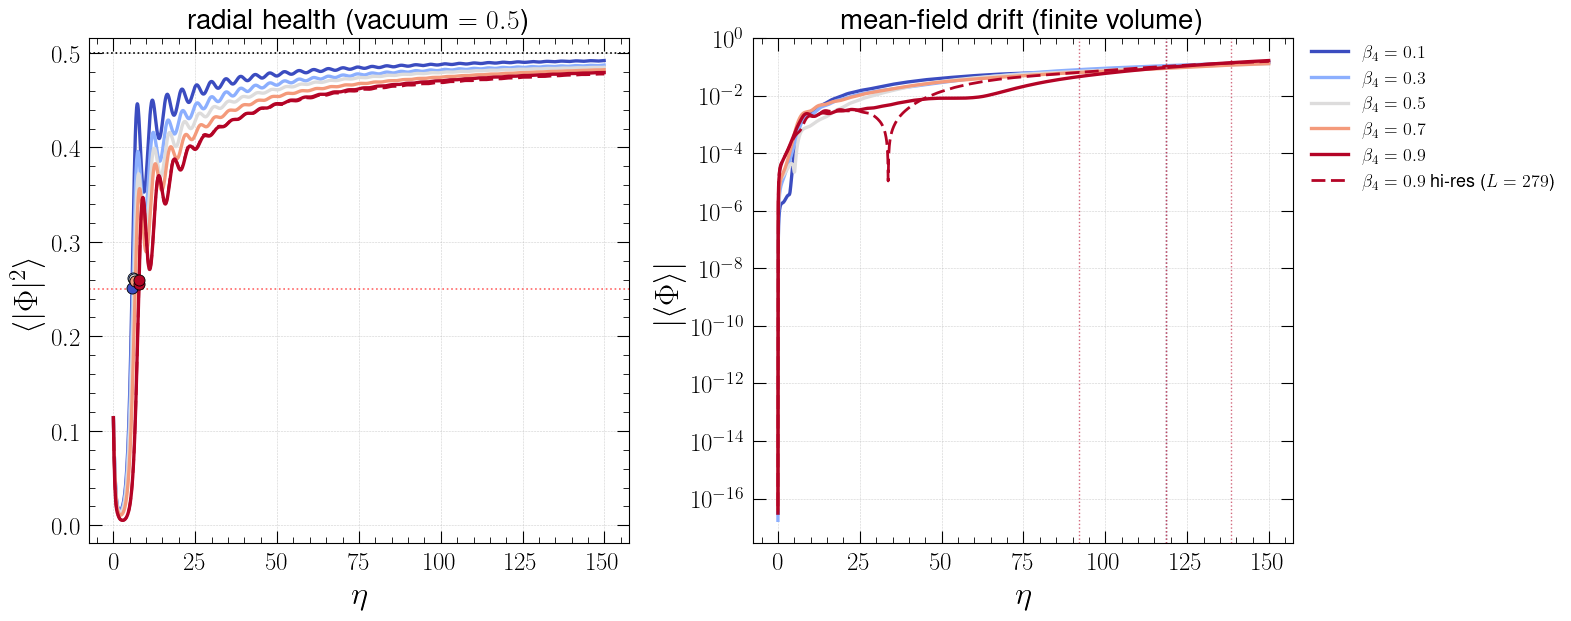

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for d in ready:
    eta, p2 = phi2_radial(d)
    axes[0].plot(eta, p2, color=d['color'], ls=d['ls'], lw=d['lw'])
    mark_breaking(axes[0], d, eta, p2)
    s0, s1 = d['scalar_0'], d['scalar_1']
    drift = np.sqrt(s0['phi']**2 + np.interp(s0['eta'], s1['eta'], s1['phi'])**2)
    axes[1].plot(s0['eta'], drift, color=d['color'], ls=d['ls'], lw=d['lw'])
axes[0].axhline(0.5,  color='k', ls=':', lw=1.2)
axes[0].axhline(0.25, color='r', ls=':', lw=1.2, alpha=0.6)
axes[1].set_yscale('log')
for d in ready:
    horizon_guides(axes[1], d)
paper_ax(axes[0], ylabel=r'$\langle|\Phi|^2\rangle$', title=r'radial health (vacuum $=0.5$)')
paper_ax(axes[1], ylabel=r'$|\langle\Phi\rangle|$',  title=r'mean-field drift (finite volume)')
add_legend(axes[1], ready)
plt.tight_layout(); plt.show()

## 2. Potential energies: is $E_{V_1}<0$ maintained?

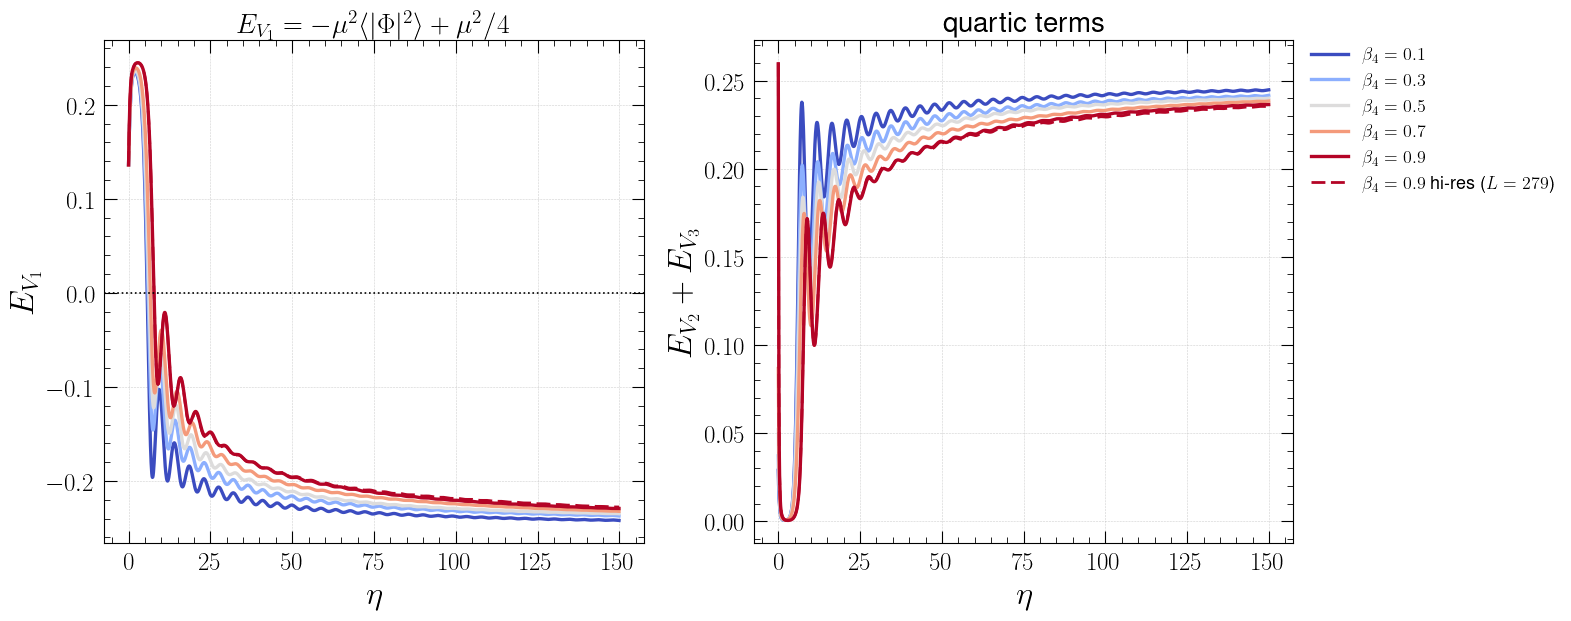

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for d in ready:
    en = d['energies']
    axes[0].plot(en['eta'], en['Ev_1'], color=d['color'], ls=d['ls'], lw=d['lw'])
    axes[1].plot(en['eta'], en['Ev_2'] + en['Ev_3'], color=d['color'], ls=d['ls'], lw=d['lw'])
axes[0].axhline(0, color='k', ls=':', lw=1.2)
paper_ax(axes[0], ylabel=r'$E_{V_1}$', title=r'$E_{V_1}=-\mu^2\langle|\Phi|^2\rangle+\mu^2/4$')
paper_ax(axes[1], ylabel=r'$E_{V_2}+E_{V_3}$', title=r'quartic terms')
add_legend(axes[1], ready)
plt.tight_layout(); plt.show()

## 3. Wall-area parameters $\mathcal{A}_1$ (adjacent) and $\mathcal{A}_2$ (non-adjacent)

$\mathcal{A} \equiv \mathrm{scal}/(2aH)$; a plateau indicates scaling.
Dotted verticals: 3- and 2-horizon marks (finite-volume effects become significant to
their right). Breaking onset ($E_{V_1}$ first $< 0$) is marked with filled circles.

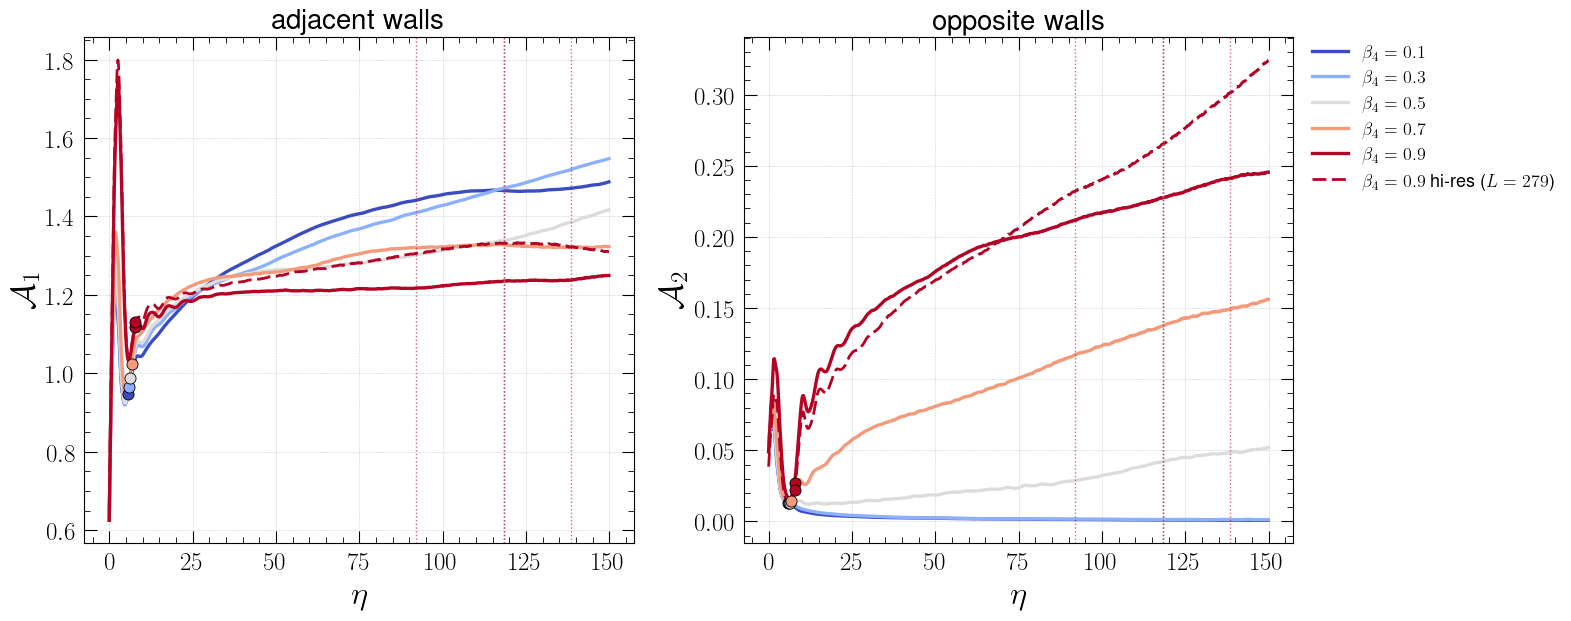

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True, sharey=False)
for d in ready:
    for ax, key in zip(axes, ['scal1', 'scal2']):
        eta, A = area_param(key, d)
        ax.plot(eta, A, color=d['color'], ls=d['ls'], lw=d['lw'])
        mark_breaking(ax, d, eta, A)
for ax in axes:
    # ax.set_xscale('log'); ax.set_yscale('log')
    for d in ready:
        horizon_guides(ax, d)
paper_ax(axes[0], ylabel=r'$\mathcal{A}_1$', title=r'adjacent walls')
paper_ax(axes[1], ylabel=r'$\mathcal{A}_2$', title=r'non-adjacent walls')
add_legend(axes[1], ready)
plt.tight_layout(); plt.show()

## 4. Local logarithmic slopes ${\rm d}\ln\mathcal{A}/{\rm d}\ln\eta$

Scaling $\Leftrightarrow$ slope $\to 0$. For $\beta_4 < 1/3$ the non-adjacent walls are
unstable (expect a persistent negative slope = decay); for $\beta_4 > 1/3$ they are
bound (do they reach a plateau, and when?). Slopes are shown only after $1.5\times$
the breaking onset $\eta$.

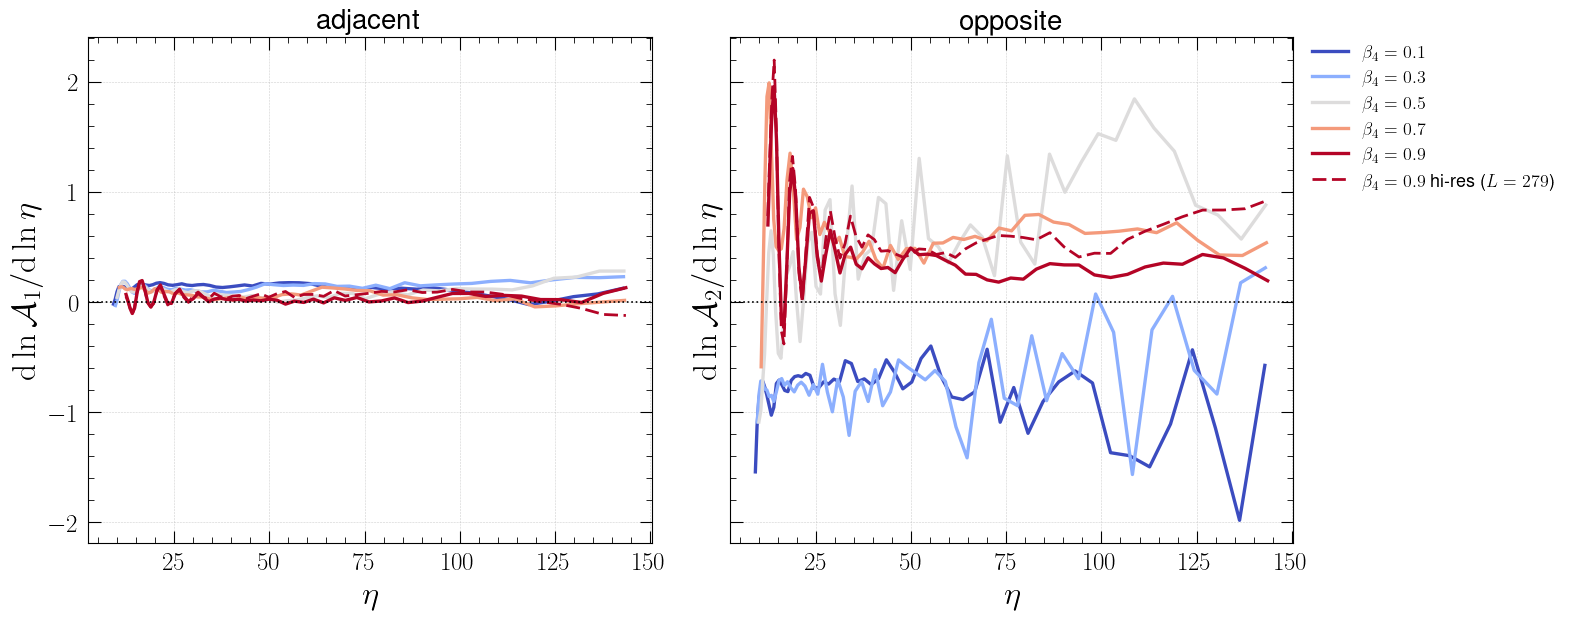

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True, sharey=True)
for d in ready:
    for ax, key in zip(axes, ['scal1','scal2']):
        eta, A = area_param(key, d)
        eb = breaking_onset_eta(d)
        if eb is not None:
            sel = eta > 1.5*eb
            xs, sl = local_logslope(eta[sel], A[sel])
            ax.plot(xs, sl, color=d['color'], ls=d['ls'], lw=d['lw'])
for ax in axes:
    ax.axhline(0, color='k', ls=':', lw=1.2)
    # ax.set_xscale('log')
# axes[0].set_ylim(-0.2, 0.2)
# axes[1].set_ylim(-3, 2)

paper_ax(axes[0], ylabel=r'${\rm d}\ln\mathcal{A}_1/{\rm d}\ln\eta$', title=r'adjacent')
paper_ax(axes[1], ylabel=r'${\rm d}\ln\mathcal{A}_2/{\rm d}\ln\eta$', title=r'non-adjacent')
add_legend(axes[1], ready)
plt.tight_layout(); plt.show()

## 5. non-adjacent-to-adjacent ratio $\mathcal{A}_2/\mathcal{A}_1$

Direct view of the $\beta_4 = 1/3$ transition: a decaying ratio means non-adjacent walls
are splitting into adjacent pairs ($\beta_4 < 1/3$); a stable or rising ratio means
the non-adjacent walls are bound ($\beta_4 > 1/3$).

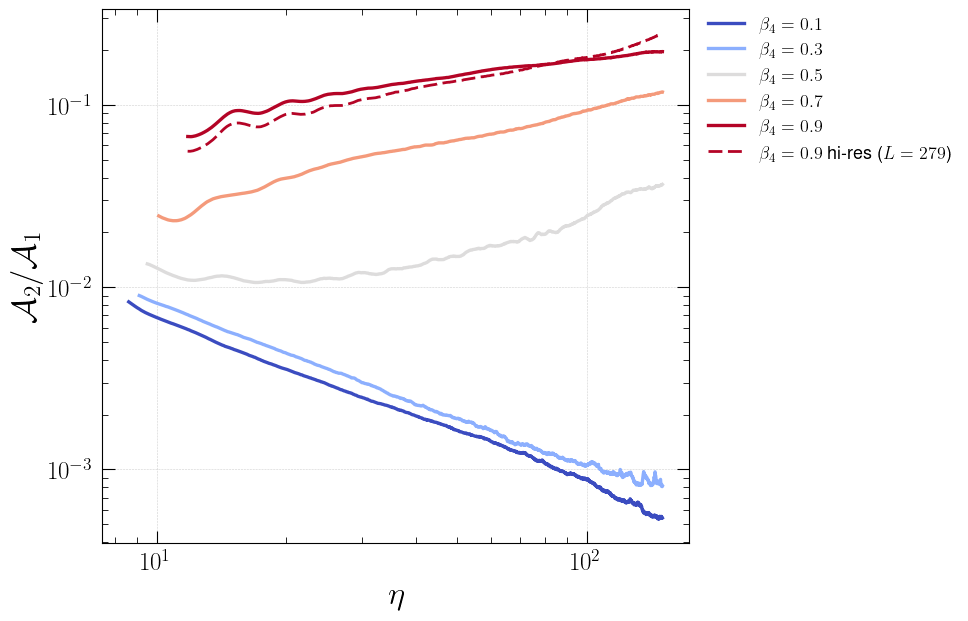

In [10]:
fig, ax = plt.subplots(figsize=(10, 6.5))
for d in ready:
    en = d['energies']
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = en['scal2'] / en['scal1']
    eb = breaking_onset_eta(d)
    sel = en['eta'] > (1.5*eb if eb is not None else 0)
    ax.plot(en['eta'][sel], ratio[sel], color=d['color'], ls=d['ls'], lw=d['lw'])
ax.set_xscale('log'); ax.set_yscale('log')
paper_ax(ax, ylabel=r'$\mathcal{A}_2/\mathcal{A}_1$')
add_legend(ax, ready)
plt.tight_layout(); plt.show()

## 6. Kinetic and gradient energies

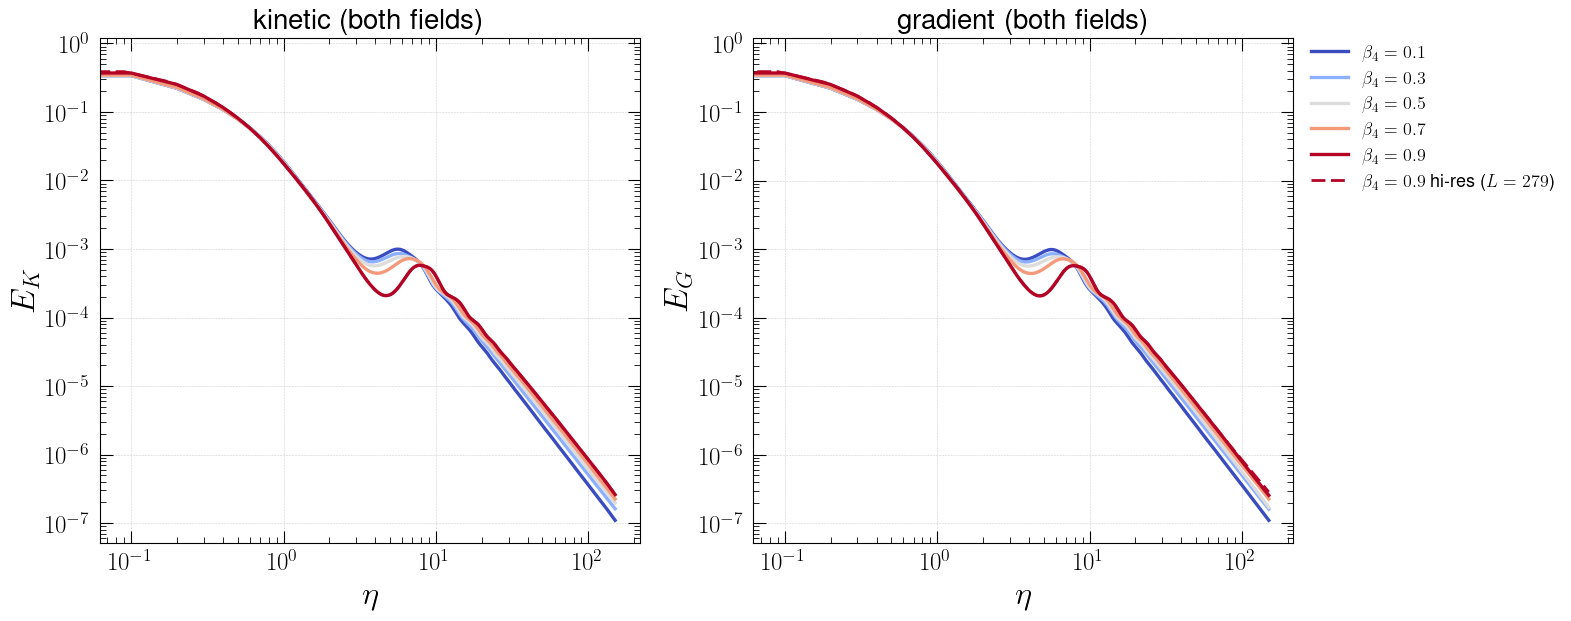

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for d in ready:
    en = d['energies']
    axes[0].plot(en['eta'], en['Ek_1'] + en['Ek_2'], color=d['color'], ls=d['ls'], lw=d['lw'])
    axes[1].plot(en['eta'], en['Eg_1'] + en['Eg_2'], color=d['color'], ls=d['ls'], lw=d['lw'])
for ax in axes:
    ax.set_xscale('log'); ax.set_yscale('log')
paper_ax(axes[0], ylabel=r'$E_K$', title=r'kinetic (both fields)')
paper_ax(axes[1], ylabel=r'$E_G$', title=r'gradient (both fields)')
add_legend(axes[1], ready)
plt.tight_layout(); plt.show()

## 7. Scalar means $\langle\phi\rangle \pm \sigma$ (per component)

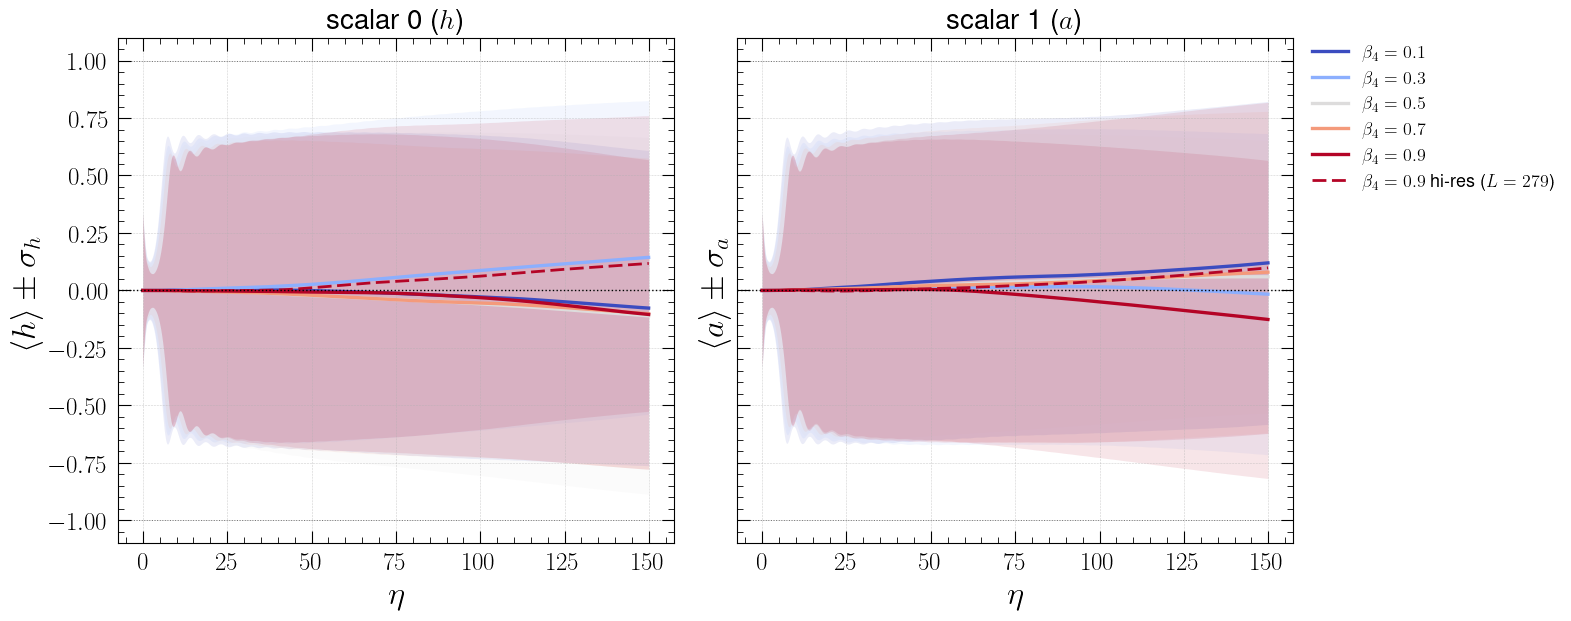

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True, sharey=True)
for d in ready:
    for ax, key in zip(axes, ['scalar_0', 'scalar_1']):
        s = d[key]
        ax.plot(s['eta'], s['phi'], color=d['color'], ls=d['ls'], lw=d['lw'])
        ax.fill_between(s['eta'], s['phi'] - s['rms_phi'], s['phi'] + s['rms_phi'],
                        color=d['color'], alpha=0.10, lw=0)
for ax in axes:
    ax.axhline(0, color='k', ls=':', lw=1.0)
    for v in (1, -1):
        ax.axhline(v, color='k', ls=':', lw=0.7, alpha=0.5)
paper_ax(axes[0], ylabel=r'$\langle h\rangle \pm \sigma_h$', title=r'scalar 0 ($h$)')
paper_ax(axes[1], ylabel=r'$\langle a\rangle \pm \sigma_a$', title=r'scalar 1 ($a$)')
add_legend(axes[1], ready)
plt.tight_layout(); plt.show()

## 8. Summary table

In [13]:
print(f"{'card':14s} {'b4':>4s} {'eta_break':>9s} {'<|Phi|2> end':>12s} {'drift end':>10s}"
      f" {'A1 end':>9s} {'A2 end':>9s} {'A2/A1 end':>9s}")
print('-'*84)
for d in ready:
    eb = breaking_onset_eta(d)
    eta, p2 = phi2_radial(d)
    s0, s1 = d['scalar_0'], d['scalar_1']
    drift = np.sqrt(s0['phi'][-1]**2 + s1['phi'][-1]**2)
    _, A1 = area_param('scal1', d)
    _, A2 = area_param('scal2', d)
    eb_s = f'{eb:9.2f}' if eb is not None else '      n/a'
    r_s  = f'{A2[-1]/A1[-1]:9.4f}' if A1[-1] else '      n/a'
    print(f"{d['name']:14s} {d['beta4']:>4.1f} {eb_s}"
          f" {p2[-1]:>12.4f} {drift:>10.4f} {A1[-1]:>9.4f} {A2[-1]:>9.4f} {r_s}")

card             b4 eta_break <|Phi|2> end  drift end    A1 end    A2 end A2/A1 end
------------------------------------------------------------------------------------
b40p1           0.1      5.70       0.4919     0.1423    1.4882    0.0008    0.0005
b40p3           0.3      6.00       0.4872     0.1449    1.5474    0.0013    0.0008
b40p5           0.5      6.30       0.4848     0.1254    1.4168    0.0519    0.0367
b40p7           0.7      6.70       0.4822     0.1287    1.3229    0.1561    0.1180
b40p9           0.9      7.80       0.4792     0.1639    1.2496    0.2455    0.1965
b40p9_hires     0.9      7.83       0.4777     0.1531    1.3099    0.3243    0.2476
